In [55]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

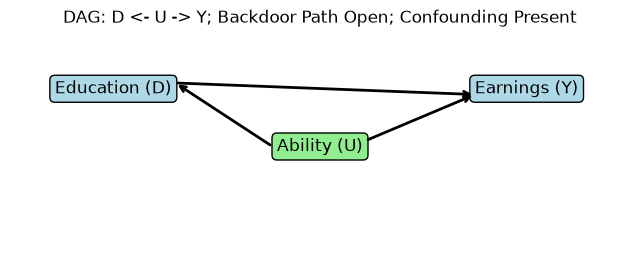

In [56]:
# DAG for confounding and the backdoor criterion
fig, ax = plt.subplots(figsize=(8,3))
ax.set_xlim(0, 3)
ax.set_ylim(0, 2)
ax.axis('off')
ax.text(0.5, 1.5, 'Education (D)', ha='center', va='center', fontsize=12, bbox=dict(boxstyle='round', fc='lightblue', ec='black'))
ax.text(1.5, 1.0, 'Ability (U)', ha='center', va='center', fontsize=12, bbox=dict(boxstyle='round', fc='lightgreen', ec='black'))
ax.text(2.5, 1.5, 'Earnings (Y)', ha='center', va='center', fontsize=12, bbox=dict(boxstyle='round', fc='lightblue', ec='black'))
#U->D
ax.annotate('', xy=(1.27, 1.00), xytext=(0.8, 1.55), arrowprops=dict(arrowstyle='<-', lw=2))
#U->Y
ax.annotate('', xy=(2.25, 1.45), xytext=(1.72, 1.05), arrowprops=dict(arrowstyle='->', lw=2))
#D->Y
ax.annotate('', xy=(0.8, 1.55), xytext=(2.25, 1.45), arrowprops=dict(arrowstyle='<-', lw=2))
ax.set_title('DAG: D <- U -> Y; Backdoor Path Open; Confounding Present')
plt.show()

In [57]:
#1. Set seed for reproducibility
np.random.seed(42)
n=10000

In [58]:
#2. Simulate the data according to the DAG
#Ability to pay (U) is a confounder that affects both the treatment (D) and the outcome (Y)
U=np.random.normal(10,2,n)

In [59]:
# Education (D) is caused by Ability +random shock
#true coefficient of Ability on Education is 0.5
D=2.0+0.5*U+np.random.normal(0,1,n)

In [60]:
#Earings(Y) is caused by Ability + Education + random shock
#true coefficient of Ability on Earnings is 5
#True causal effect of Education on Earnings is 2
Y=10+5.0*U+2.0*D+np.random.normal(0,2,n)

In [61]:
#Combine into a DataFrame
df=pd.DataFrame({'Ability':U,'Education':D,'Earnings':Y})

In [62]:
#Model 1: The naive model that does not control for the confounder (Ability)
model1=sm.OLS(df['Earnings'],df['Education']).fit()
print("Model 1: Naive model (no control for Ability)")
print(model1.summary())
print(f"Estimated effect of Education on Earnings: {model1.params['Education']:.4f} (True Effect: 2.0000)\n")

Model 1: Naive model (no control for Ability)
                                 OLS Regression Results                                
Dep. Variable:               Earnings   R-squared (uncentered):                   0.986
Model:                            OLS   Adj. R-squared (uncentered):              0.986
Method:                 Least Squares   F-statistic:                          7.130e+05
Date:                Wed, 22 Jul 2026   Prob (F-statistic):                        0.00
Time:                        14:29:33   Log-Likelihood:                         -35961.
No. Observations:               10000   AIC:                                  7.192e+04
Df Residuals:                    9999   BIC:                                  7.193e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.

In [63]:
#Model 2: The true model that controls for the confounder (Ability)
model2=sm.OLS(df['Earnings'],sm.add_constant(df[['Education','Ability']])).fit()
print("Model 2: True model (controls for Ability Backdoor Path Closed)")
print(model2.summary())
print(f"Estimated effect of Education on Earnings: {model2.params['Education']:.4f}   (True effect is 2.0)\n")    

Model 2: True model (controls for Ability Backdoor Path Closed)
                            OLS Regression Results                            
Dep. Variable:               Earnings   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                 1.911e+05
Date:                Wed, 22 Jul 2026   Prob (F-statistic):               0.00
Time:                        14:29:33   Log-Likelihood:                -21027.
No. Observations:               10000   AIC:                         4.206e+04
Df Residuals:                    9997   BIC:                         4.208e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------